## import libraries

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import umap
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import HDBSCAN

## load embeddings

In [39]:
root_embeddings = "_data/embeddings_exports"

In [40]:
def load_embeddings(folder: str, glob_pattern: str = "*.parquet") -> pd.DataFrame:
    """Load all parquets, parsing crop/country/year from filename."""
    dfs = []
    for path in Path(folder).glob(glob_pattern):
        # e.g. maize_corn_popcorn_at_2019_embedding.parquet
        stem = path.stem.replace("_embedding", "")
        *crop_parts, country, year = stem.split("_")
        df = pd.read_parquet(path)
        df["crop"] = "_".join(crop_parts)
        df["country"] = country
        df["year"] = int(year)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [41]:
dataset = load_embeddings(root_embeddings)
dataset.head(3)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country
0,10.65,56.45,702.0,416.0,EPSG:32632,"[3.1441202, -0.40016073, 1.2004822, 2.1151354,...","[10.664917617831682, 56.43730676496256]",maize_corn_popcorn,dk,2019,dk
1,9.05,54.95,393.0,477.0,EPSG:32632,"[3.6699157, 0.42549747, 2.7125463, 4.7336593, ...","[9.07457125556681, 54.96468696472927]",maize_corn_popcorn,dk,2019,dk
2,9.25,55.55,1014.0,97.0,EPSG:32632,"[4.9585056, 0.7512887, -0.30051547, 1.8531787,...","[9.214983631495008, 55.508991389369086]",maize_corn_popcorn,dk,2019,dk


## reduce embeddings

In [42]:
# Diagnose first
def inspect_embedding_nulls(df: pd.DataFrame, embedding_col: str = "embedding"):
    col = df[embedding_col]
    print(f"Total rows:        {len(col)}")
    print(f"None:              {col.isna().sum()}")
    print(f"Scalar NaN:        {col.apply(lambda x: isinstance(x, float) and np.isnan(x)).sum()}")
    print(f"Array with NaN:    {col.apply(lambda x: isinstance(x, np.ndarray) and np.any(np.isnan(x))).sum()}")
    print(f"Empty list/array:  {col.apply(lambda x: hasattr(x, '__len__') and len(x) == 0).sum()}")
    
    # Show a sample of the problematic rows
    bad = col[col.apply(lambda x: not isinstance(x, (np.ndarray, list)) or (hasattr(x, '__len__') and len(x) == 0))]
    print(f"\nSample bad values:\n{bad.head(5)}")
    print(f"\nTypes found: {col.apply(type).value_counts().to_dict()}")

inspect_embedding_nulls(dataset)

Total rows:        3500
None:              0
Scalar NaN:        0
Array with NaN:    5
Empty list/array:  0

Sample bad values:
Series([], Name: embedding, dtype: object)

Types found: {<class 'numpy.ndarray'>: 3500}


In [43]:
def is_valid_embedding(x):
    arr = np.asarray(x, dtype=np.float32)
    return np.all(np.isfinite(arr))  # catches NaN and inf in one shot

In [51]:
def filter_valid_embeddings(df: pd.DataFrame, embedding_col: str = "embedding") -> pd.DataFrame:
    valid_mask = df[embedding_col].apply(lambda x: np.all(np.isfinite(x.astype(np.float32))))
    n_dropped = (~valid_mask).sum()
    if n_dropped > 0:
        print(f"Dropping {n_dropped}/{len(df)} rows with NaN/Inf embeddings.")
    return df[valid_mask].reset_index(drop=True)

In [52]:
def reduce_embeddings(
    df: pd.DataFrame,
    embedding_col: str = "embedding",
    method: str = "umap",
    n_components: int = 2,
    **kwargs
) -> pd.DataFrame:

    valid_mask = df[embedding_col].apply(
        lambda x: np.all(np.isfinite(x.astype(np.float32)))
    )

    n_dropped = (~valid_mask).sum()
    if n_dropped > 0:
        print(f"Dropping {n_dropped}/{len(df)} rows with NaN/Inf in embedding.")

    df_valid = df[valid_mask].reset_index(drop=True)
    emb_matrix = np.stack(df_valid[embedding_col].values).astype(np.float32)

    if method == "umap":
        reducer = umap.UMAP(n_components=n_components, **kwargs)
    elif method == "pca":
        reducer = PCA(n_components=n_components, **kwargs)
    else:
        raise ValueError(f"Unknown method: {method}")

    reduced = reducer.fit_transform(emb_matrix)

    meta_cols = [c for c in df_valid.columns if c != embedding_col]
    result = df_valid[meta_cols].copy()
    for i in range(n_components):
        result[f"dim_{i+1}"] = reduced[:, i]

    return result

In [53]:
df_reduced = reduce_embeddings(dataset, embedding_col="embedding", method="umap", n_components=2)
df_reduced.head(3)

Dropping 5/3500 rows with NaN/Inf in embedding.


,tile_lon,tile_lat,pixel_row,pixel_col,crs,long_lat,crop,country_id,year,country,dim_1,dim_2
0,10.65,56.45,702.0,416.0,EPSG:32632,"[10.664917617831682, 56.43730676496256]",maize_corn_popcorn,dk,2019,dk,15.153690,-0.070825
1,9.05,54.95,393.0,477.0,EPSG:32632,"[9.07457125556681, 54.96468696472927]",maize_corn_popcorn,dk,2019,dk,14.313162,0.222256
2,9.25,55.55,1014.0,97.0,EPSG:32632,"[9.214983631495008, 55.508991389369086]",maize_corn_popcorn,dk,2019,dk,15.508362,-1.037809


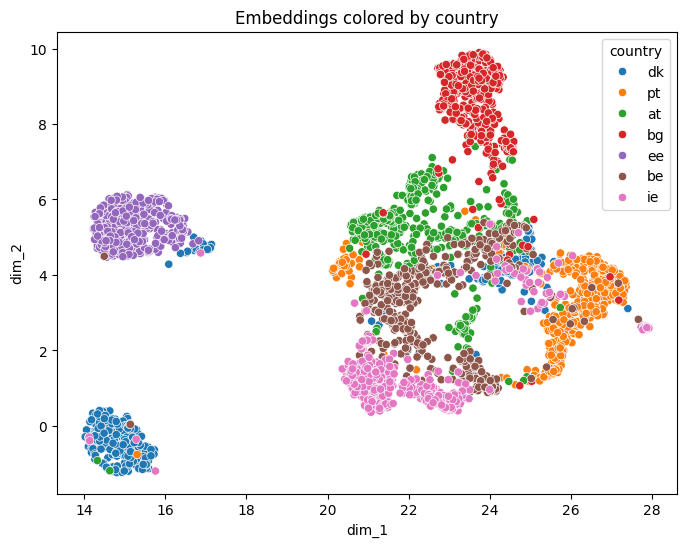

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_reduced,
    x="dim_1",
    y="dim_2",
    hue="country"
)

plt.title("Embeddings colored by country")
plt.show()

## analysis

In [55]:
def get_emb_matrix(df: pd.DataFrame, embedding_col: str = "embedding") -> np.ndarray:
    return np.stack(df[embedding_col].values).astype(np.float32)

def country_similarity_matrix(df: pd.DataFrame, embedding_col: str = "embedding") -> pd.DataFrame:
    means = df.groupby("country")[embedding_col].apply(
        lambda x: np.stack(x.values).mean(axis=0)
    )
    sim = cosine_similarity(np.stack(means.values))
    return pd.DataFrame(sim, index=means.index, columns=means.index)

def cluster_embeddings(df: pd.DataFrame, embedding_col: str = "embedding", min_cluster_size: int = 5, **kwargs) -> pd.Series:
    emb = get_emb_matrix(df, embedding_col)
    labels = HDBSCAN(min_cluster_size=min_cluster_size, **kwargs).fit_predict(emb)
    return pd.Series(labels, index=df.index, name="cluster")

def embedding_variance_by_group(df: pd.DataFrame, group: str = "country", embedding_col: str = "embedding") -> pd.Series:
    return df.groupby(group)[embedding_col].apply(
        lambda x: float(np.var(np.stack(x.values), axis=0).mean())
    ).rename("intra_variance")

def temporal_drift(df: pd.DataFrame, embedding_col: str = "embedding") -> pd.DataFrame:
    records = []
    for country, grp in df.groupby("country"):
        yearly = grp.groupby("year")[embedding_col].apply(
            lambda x: np.stack(x.values).mean(axis=0)
        ).sort_index()
        vecs = np.stack(yearly.values)
        years = list(yearly.index)
        for i in range(len(vecs) - 1):
            drift = 1 - cosine_similarity([vecs[i]], [vecs[i+1]])[0][0]
            records.append({"country": country, "year_from": years[i], "year_to": years[i+1], "drift": drift})
    return pd.DataFrame(records)

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

def run_spatial_generalization_analysis(
    df: pd.DataFrame,
    embedding_col: str = "embedding",
    reduced_col_prefix: str = "dim",
):
    df = filter_valid_embeddings(df, embedding_col=embedding_col)
    # ── 1. DIMENSIONALITY REDUCTION ──────────────────────────────────────────
    print("=== 1. Dimensionality Reduction ===")
    df_reduced = reduce_embeddings(df, embedding_col=embedding_col, method="umap", n_components=2,
                                   random_state=42, n_neighbors=15, min_dist=0.1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=df_reduced, x="dim_1", y="dim_2", hue="country",
                    alpha=0.6, s=20, ax=axes[0])
    axes[0].set_title("UMAP — colored by country")
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)

    sns.scatterplot(data=df_reduced, x="dim_1", y="dim_2", hue="year",
                    alpha=0.6, s=20, palette="viridis", ax=axes[1])
    axes[1].set_title("UMAP — colored by year")

    plt.tight_layout()
    plt.savefig("umap_projection.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 2. COUNTRY SIMILARITY MATRIX ─────────────────────────────────────────
    print("\n=== 2. Country Similarity Matrix ===")
    sim_matrix = country_similarity_matrix(df, embedding_col=embedding_col)

    plt.figure(figsize=(10, 8))
    mask = np.eye(len(sim_matrix), dtype=bool)   # mask diagonal (self-similarity = 1)
    sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
                mask=mask, vmin=0, vmax=1, linewidths=0.5)
    plt.title("Mean embedding cosine similarity between countries")
    plt.tight_layout()
    plt.savefig("country_similarity.png", dpi=150, bbox_inches="tight")
    plt.show()

    

    stacked = sim_matrix.copy()
    stacked.index.name = "country_a"
    stacked.columns.name = "country_b"

    sim_pairs = (
        stacked.where(~mask)
        .stack()
        .reset_index()
        .rename(columns={0: "similarity"})
        .sort_values("similarity", ascending=False)
        .reset_index(drop=True)
    )

    print("Most similar country pairs:\n", sim_pairs.head(5).to_string(index=False))
    print("Least similar country pairs:\n", sim_pairs.tail(5).to_string(index=False))

    # ── 3. CLUSTERING ─────────────────────────────────────────────────────────
    print("\n=== 3. Clustering (HDBSCAN) ===")
    # Run on reduced embeddings for stability — faster and less noisy
    cluster_labels = cluster_embeddings(df_reduced.assign(
        embedding=list(np.stack([df_reduced["dim_1"], df_reduced["dim_2"]]).T)
    ), embedding_col="embedding", min_cluster_size=10)

    df_reduced["cluster"] = cluster_labels.values
    n_clusters = (cluster_labels != -1).unique().shape[0]
    n_noise = (cluster_labels == -1).sum()
    print(f"Clusters found: {cluster_labels.nunique()} (including noise=-1)")
    print(f"Noise points: {n_noise} ({100*n_noise/len(df_reduced):.1f}%)")

    # How do clusters map to countries?
    cluster_country = pd.crosstab(df_reduced["cluster"], df_reduced["country"], normalize="index").round(2)
    print("\nCluster composition by country (row-normalized):\n", cluster_country)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_reduced, x="dim_1", y="dim_2", hue="cluster",
                    palette="tab20", alpha=0.6, s=20)
    plt.title("UMAP — HDBSCAN clusters")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.savefig("umap_clusters.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 4. INTRA-COUNTRY VARIANCE ─────────────────────────────────────────────
    print("\n=== 4. Intra-country Embedding Variance ===")
    variance = embedding_variance_by_group(df, group="country", embedding_col=embedding_col).sort_values(ascending=False)
    print(variance)

    plt.figure(figsize=(10, 4))
    variance.plot(kind="bar", color="steelblue", edgecolor="white")
    plt.title("Intra-country embedding variance\n(higher = more heterogeneous fields)")
    plt.ylabel("Mean variance across embedding dims")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("intra_country_variance.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 5. TEMPORAL DRIFT ─────────────────────────────────────────────────────
    if df["year"].nunique() > 1:
        print("\n=== 5. Temporal Drift per Country ===")
        drift_df = temporal_drift(df, embedding_col=embedding_col)
        print(drift_df.sort_values("drift", ascending=False).to_string(index=False))

        plt.figure(figsize=(12, 5))
        for country, grp in drift_df.groupby("country"):
            grp = grp.sort_values("year_from")
            plt.plot(grp["year_from"].astype(str) + "→" + grp["year_to"].astype(str),
                     grp["drift"], marker="o", label=country)
        plt.title("Year-over-year embedding drift per country\n(higher = larger shift in crop signature)")
        plt.ylabel("Cosine distance")
        plt.xlabel("Year transition")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
        plt.tight_layout()
        plt.savefig("temporal_drift.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("\nOnly one year in dataset — skipping temporal drift.")

    # ── 6. SPATIAL MAP ────────────────────────────────────────────────────────
    print("\n=== 6. Spatial Distribution (lon/lat) ===")
    # Extract lon/lat from long_lat column if it exists
    if "long_lat" in df_reduced.columns:
        df_reduced["lon"] = df_reduced["long_lat"].apply(lambda x: x[0] if hasattr(x, '__len__') else np.nan)
        df_reduced["lat"] = df_reduced["long_lat"].apply(lambda x: x[1] if hasattr(x, '__len__') else np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    scatter = axes[0].scatter(df_reduced["lon"], df_reduced["lat"],
                               c=df_reduced["dim_1"], cmap="RdYlBu", s=5, alpha=0.7)
    plt.colorbar(scatter, ax=axes[0], label="UMAP dim_1")
    axes[0].set_title("Spatial distribution — UMAP dim_1")
    axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

    scatter2 = axes[1].scatter(df_reduced["lon"], df_reduced["lat"],
                                c=df_reduced["cluster"], cmap="tab20", s=5, alpha=0.7)
    plt.colorbar(scatter2, ax=axes[1], label="Cluster")
    axes[1].set_title("Spatial distribution — clusters")
    axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")

    plt.tight_layout()
    plt.savefig("spatial_map.png", dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "df_reduced": df_reduced,
        "similarity_matrix": sim_matrix,
        "variance": variance,
        "drift": drift_df if df["year"].nunique() > 1 else None,
    }

Dropping 5/3500 rows with NaN/Inf embeddings.
=== 1. Dimensionality Reduction ===


/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


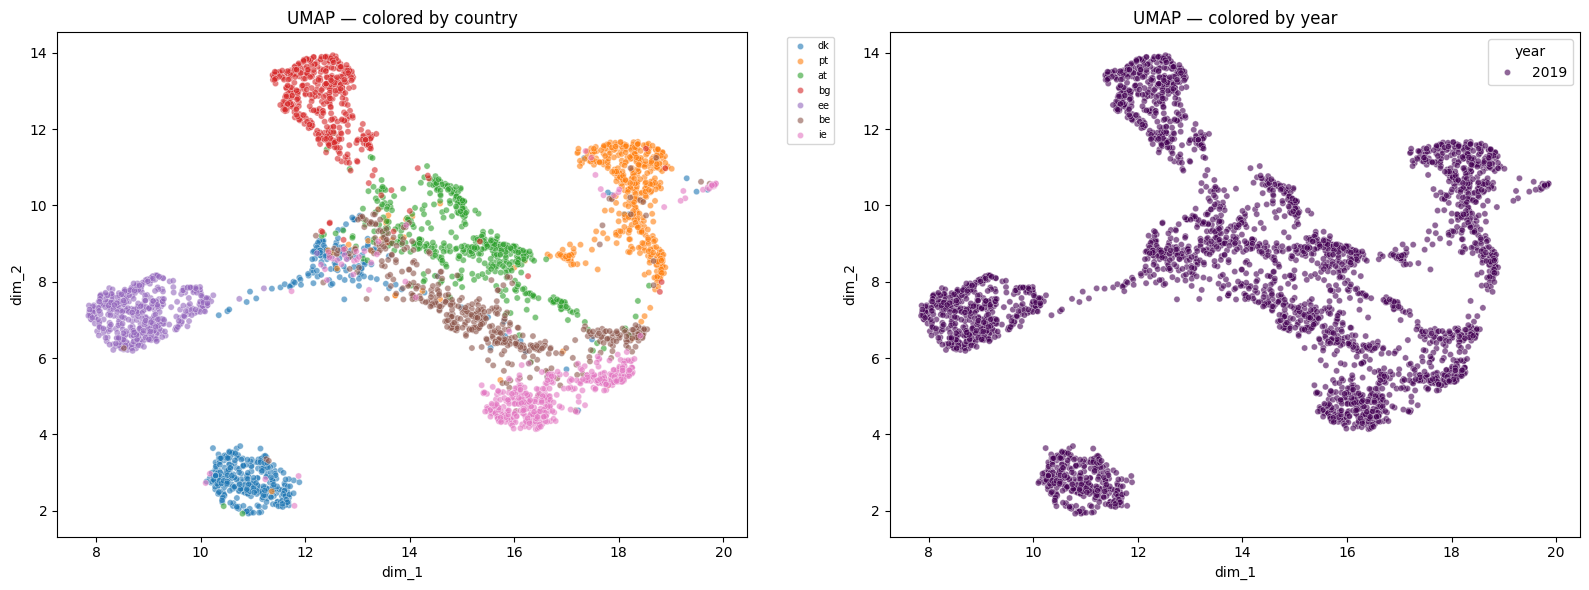


=== 2. Country Similarity Matrix ===


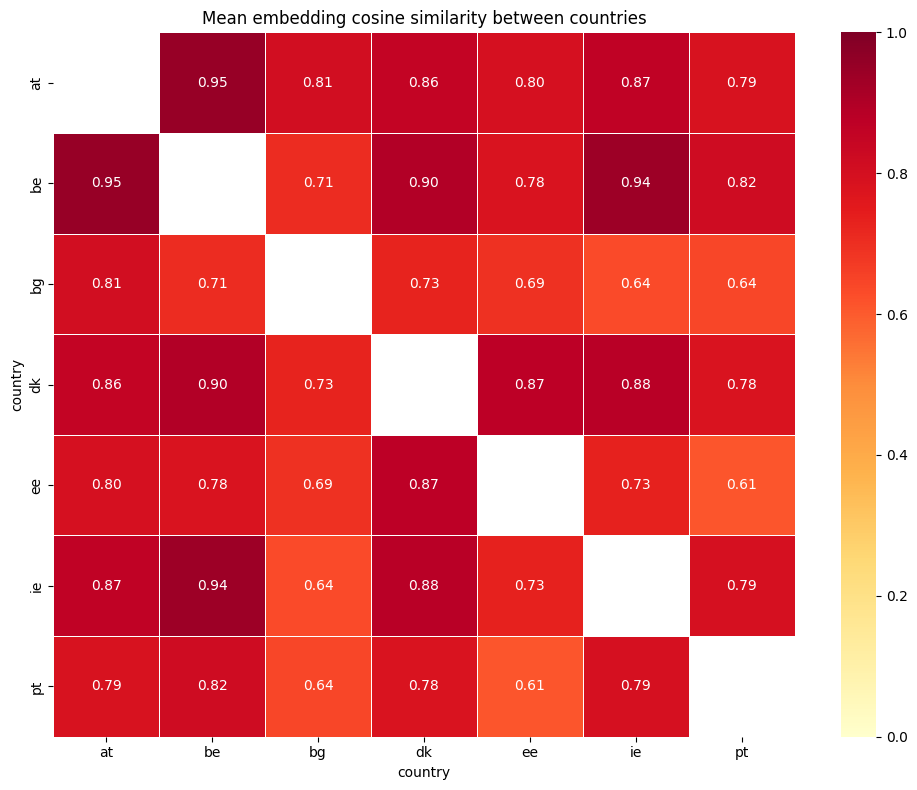

Most similar country pairs:
 country_a country_b  similarity
       at        be    0.951959
       be        at    0.951959
       be        ie    0.939569
       ie        be    0.939569
       dk        be    0.895525
Least similar country pairs:
 country_a country_b  similarity
       pt        bg    0.641984
       ie        bg    0.636088
       bg        ie    0.636088
       ee        pt    0.610910
       pt        ee    0.610910

=== 3. Clustering (HDBSCAN) ===
Clusters found: 33 (including noise=-1)
Noise points: 705 (20.2%)

Cluster composition by country (row-normalized):
 country    at    be    bg    dk    ee    ie    pt
cluster                                          
-1       0.22  0.27  0.27  0.12  0.00  0.09  0.03
 0       0.01  0.01  0.00  0.97  0.00  0.01  0.00
 1       0.00  0.00  0.00  0.01  0.99  0.00  0.00
 2       0.00  0.06  0.00  0.09  0.00  0.85  0.00
 3       0.00  0.03  0.01  0.01  0.00  0.02  0.93
 4       0.00  0.00  1.00  0.00  0.00  0.00  0.00
 5     

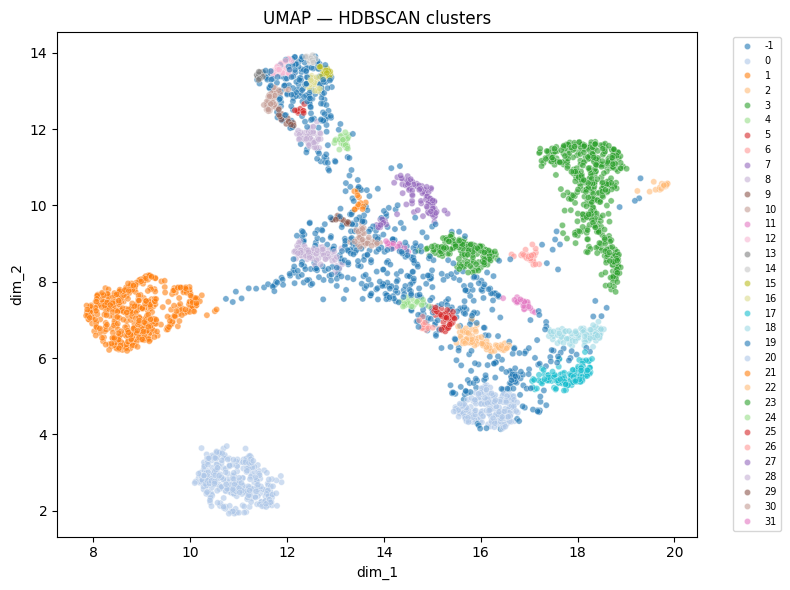


=== 4. Intra-country Embedding Variance ===
country
pt    2.731071
at    2.000900
bg    1.919305
dk    1.835431
be    1.788116
ie    1.687905
ee    1.154952
Name: intra_variance, dtype: float64


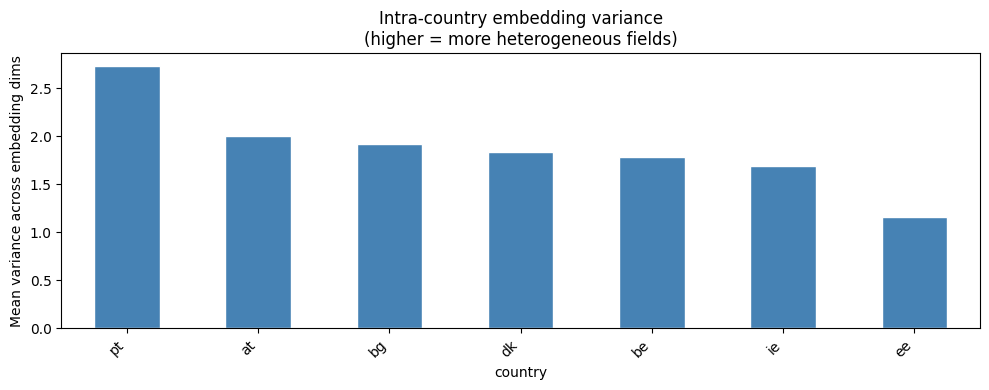


Only one year in dataset — skipping temporal drift.

=== 6. Spatial Distribution (lon/lat) ===


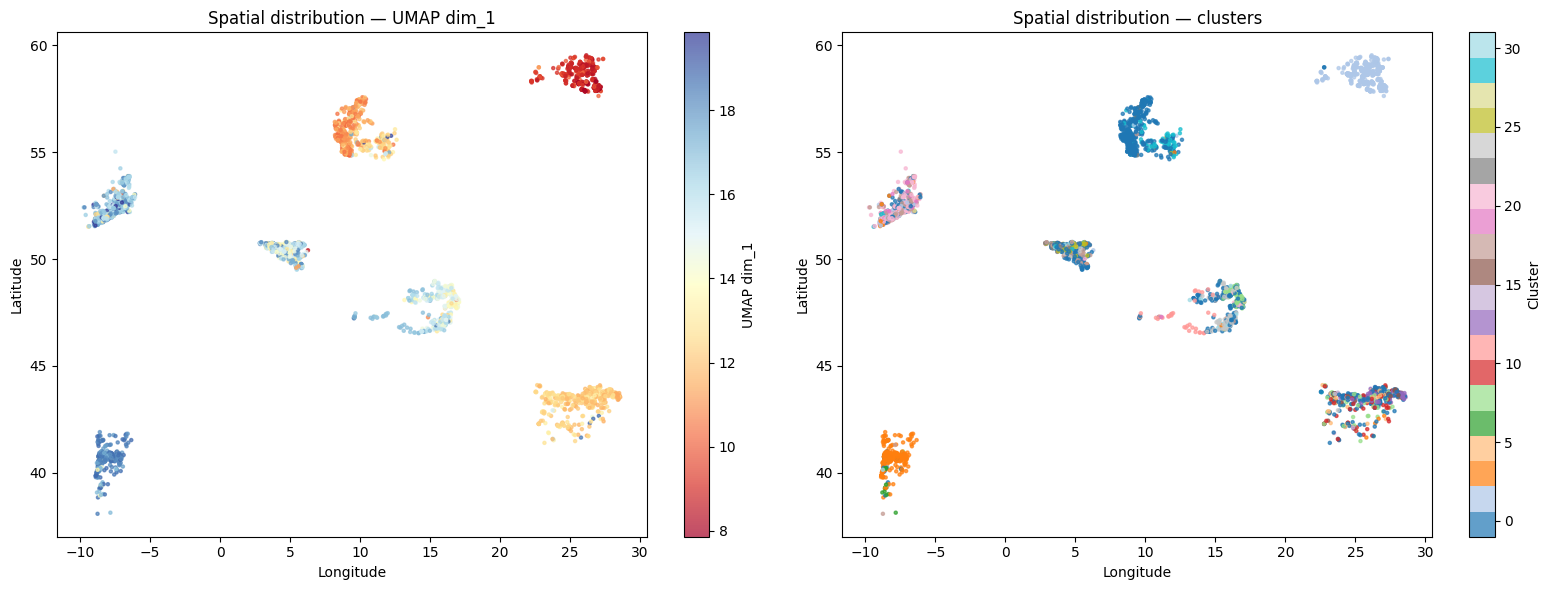

,tile_lon,tile_lat,pixel_row,pixel_col,crs,long_lat,crop,country_id,year,country,dim_1,dim_2,cluster,lon,lat
0,10.65,56.45,702.0,416.0,EPSG:32632,"[10.664917617831682, 56.43730676496256]",maize_corn_popcorn,dk,2019,dk,11.270336,3.188067,0,10.664918,56.437307
1,9.05,54.95,393.0,477.0,EPSG:32632,"[9.07457125556681, 54.96468696472927]",maize_corn_popcorn,dk,2019,dk,10.483612,3.392629,0,9.074571,54.964687
2,9.25,55.55,1014.0,97.0,EPSG:32632,"[9.214983631495008, 55.508991389369086]",maize_corn_popcorn,dk,2019,dk,11.640681,2.223207,0,9.214984,55.508991
3,10.45,55.55,549.0,171.0,EPSG:32632,"[10.42553795816323, 55.55154802322216]",maize_corn_popcorn,dk,2019,dk,12.324690,8.661815,28,10.425538,55.551548
4,12.25,55.75,288.0,174.0,EPSG:32633,"[12.222499076758965, 55.77459002960087]",maize_corn_popcorn,dk,2019,dk,19.487257,10.361064,2,12.222499,55.774590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3490,-6.55,53.85,643.0,589.0,EPSG:32629,"[-6.513608186529965, 53.842423669420256]",maize_corn_popcorn,ie,2019,ie,16.281794,4.852006,20,-6.513608,53.842424
3491,-6.55,53.85,618.0,351.0,EPSG:32629,"[-6.549612578784012, 53.84541979470222]",maize_corn_popcorn,ie,2019,ie,16.283087,4.853428,20,-6.549613,53.845420
3492,-6.95,53.55,193.0,59.0,EPSG:32629,"[-6.991711523475552, 53.58420488967147]",maize_corn_popcorn,ie,2019,ie,16.638765,5.424010,19,-6.991712,53.584205
3493,-6.95,53.55,167.0,55.0,EPSG:32629,"[-6.992292831913841, 53.58649247674237]",maize_corn_popcorn,ie,2019,ie,16.714628,5.525676,19,-6.992293,53.586492


In [62]:
results = run_spatial_generalization_analysis(dataset, embedding_col="embedding")

# Access any result afterwards
results["similarity_matrix"]
results["variance"]
results["drift"]
results["df_reduced"]  # has dim_1, dim_2, cluster + all metadata